In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [18]:
!pip install -q kaggle

In [19]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle (1).json


In [20]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [21]:
!kaggle datasets list -s "intel image classification"

ref                                                             title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
puneet6060/intel-image-classification                           Intel Image Classification                         363152213  2019-01-30 09:22:58.647000         203408       1753  0.75             
blourdhuraju/intel-image-classification-dataset                 Intel Image Classification Dataset                 254806489  2026-03-02 10:31:51.357000           1134         17  0.625            
mosabbirahmed/intel-image-classification-no-splits              Intel Image Classification | No Splits             252116383  2026-09-03 09:56:04.013000              9          5  0.75             
kkhandekar

In [22]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [23]:
!unzip -q intel-image-classification.zip -d dataset

replace dataset/seg_pred/seg_pred/10004.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace dataset/seg_pred/seg_pred/10005.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [24]:
!find dataset -maxdepth 3 -type d

dataset
dataset/seg_pred
dataset/seg_pred/seg_pred
dataset/seg_train
dataset/seg_train/seg_train
dataset/seg_train/seg_train/sea
dataset/seg_train/seg_train/forest
dataset/seg_train/seg_train/mountain
dataset/seg_train/seg_train/street
dataset/seg_train/seg_train/buildings
dataset/seg_train/seg_train/glacier
dataset/seg_test
dataset/seg_test/seg_test
dataset/seg_test/seg_test/sea
dataset/seg_test/seg_test/forest
dataset/seg_test/seg_test/mountain
dataset/seg_test/seg_test/street
dataset/seg_test/seg_test/buildings
dataset/seg_test/seg_test/glacier


In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [26]:
TRAIN_DIR = "dataset/seg_train/seg_train"
TEST_DIR = "dataset/seg_test/seg_test"

print("Training directory:", TRAIN_DIR)
print("Testing directory:", TEST_DIR)

Training directory: dataset/seg_train/seg_train
Testing directory: dataset/seg_test/seg_test


In [27]:
classes = sorted(os.listdir(TRAIN_DIR))

print("Classes:")
for i, class_name in enumerate(classes):
    print(i, class_name)

print("Number of classes:", len(classes))

Classes:
0 buildings
1 forest
2 glacier
3 mountain
4 sea
5 street
Number of classes: 6


In [28]:
for class_name in classes:
    class_path = os.path.join(TRAIN_DIR, class_name)
    count = len(os.listdir(class_path))
    print(f"{class_name:12s}: {count}")

buildings   : 2191
forest      : 2271
glacier     : 2404
mountain    : 2512
sea         : 2274
street      : 2382


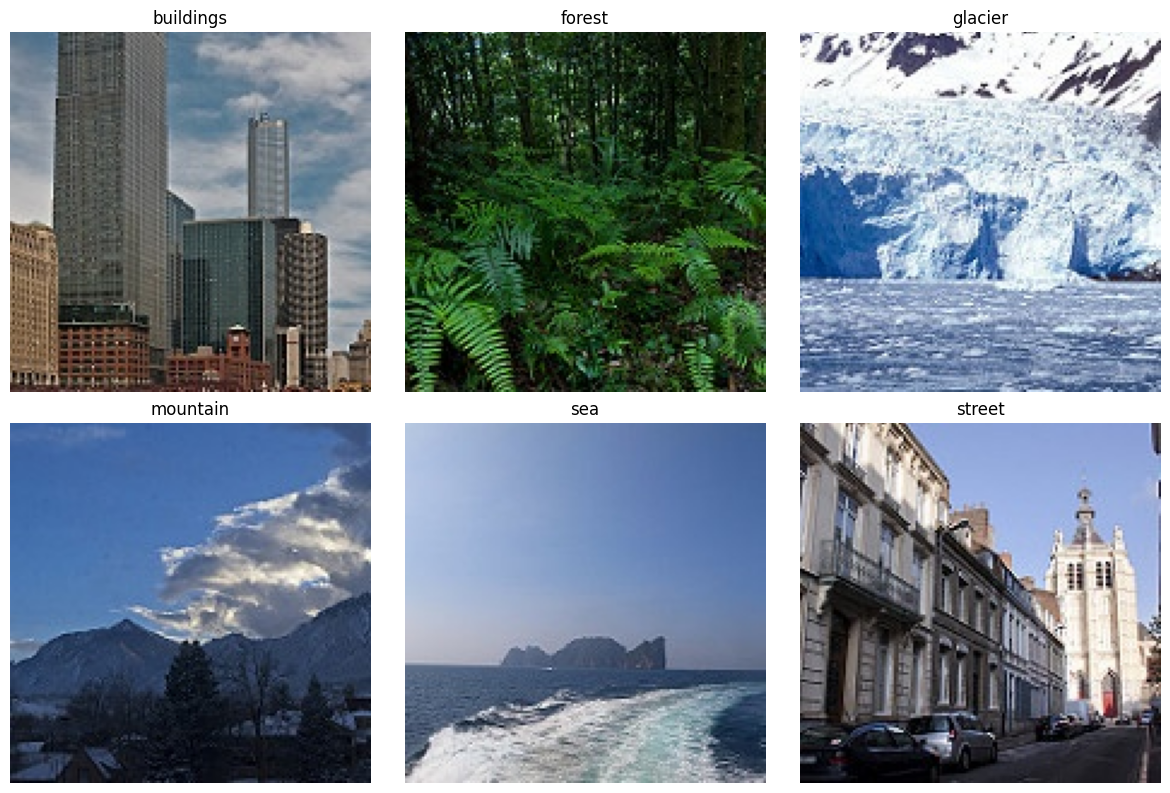

In [29]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(TRAIN_DIR, class_name)

    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = plt.imread(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

In [31]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [32]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 3000 files belonging to 6 classes.


In [33]:
class_names = train_ds.class_names

print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [34]:
normalization_layer = layers.Rescaling(1./255)

In [35]:
train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

In [36]:
ann_model = keras.Sequential([

    layers.Input(shape=(128, 128, 3)),

    layers.Flatten(),

    layers.Dense(512, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),

    layers.Dense(6, activation="softmax")
])

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,166,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,331,334 (96.63 MB)

 Trainable params: 25,331,334 (96.63 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
ann_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [39]:
EPOCHS = 15

ann_history = ann_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.2504 - loss: 2.7397 - val_accuracy: 0.3443 - val_loss: 1.5917
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.2868 - loss: 1.6589 - val_accuracy: 0.2812 - val_loss: 1.6524
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.3023 - loss: 1.6299 - val_accuracy: 0.3681 - val_loss: 1.5394
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3152 - loss: 1.6128 - val_accuracy: 0.4073 - val_loss: 1.4894
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.3188 - loss: 1.6018 - val_accuracy: 0.3917 - val_loss: 1.5423
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3184 - loss: 1.5865 - val_accuracy: 0.3981 - val_loss: 1.4813
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.3202 - loss: 1.5914 - val_accuracy: 0.3888 - val_loss: 1.5428
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.3307 - loss: 1.5786 - val_

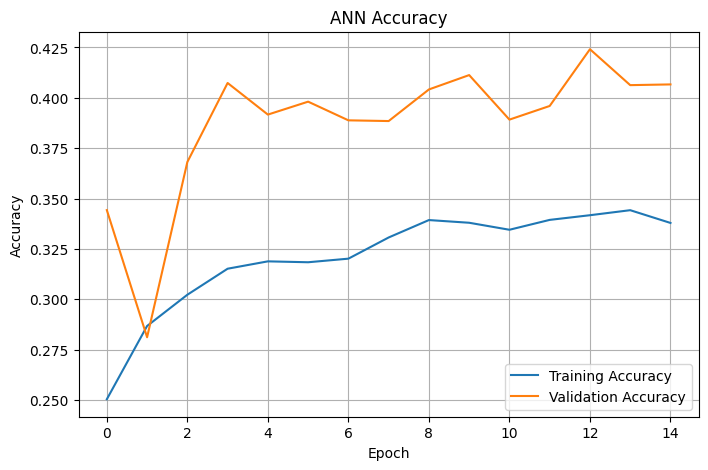

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    ann_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    ann_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Accuracy")
plt.legend()
plt.grid()
plt.show()

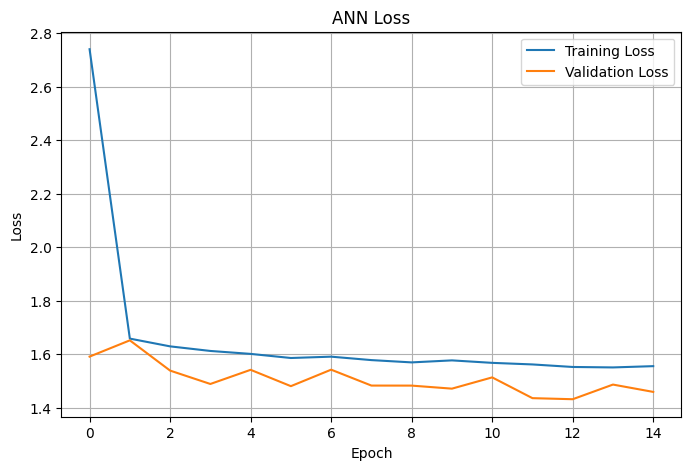

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    ann_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    ann_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Loss")
plt.legend()
plt.grid()
plt.show()

In [42]:
ann_model.save("ann_model.keras")

In [43]:
ann_loss, ann_accuracy = ann_model.evaluate(test_ds)

print("ANN Test Loss:", ann_loss)
print("ANN Test Accuracy:", ann_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4053 - loss: 1.4842
ANN Test Loss: 1.4842361211776733
ANN Test Accuracy: 0.40533334016799927


In [44]:
cnn_model = keras.Sequential([

    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(6, activation="softmax")
])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,454 (16.36 MB)

 Trainable params: 4,288,454 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [46]:
cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.5618 - loss: 1.1363 - val_accuracy: 0.6793 - val_loss: 0.8484
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.7013 - loss: 0.8137 - val_accuracy: 0.7067 - val_loss: 0.7792
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.7559 - loss: 0.6647 - val_accuracy: 0.8019 - val_loss: 0.5510
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.8036 - loss: 0.5445 - val_accuracy: 0.7994 - val_loss: 0.5640
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.8327 - loss: 0.4684 - val_accuracy: 0.8040 - val_loss: 0.5665
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8584 - loss: 0.3876 - val_accuracy: 0.8079 - val_loss: 0.5815
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8805 - loss: 0.3333 - val_accuracy: 0.8247 - val_loss: 0.5741
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9025 - loss: 0.2753 - val_acc

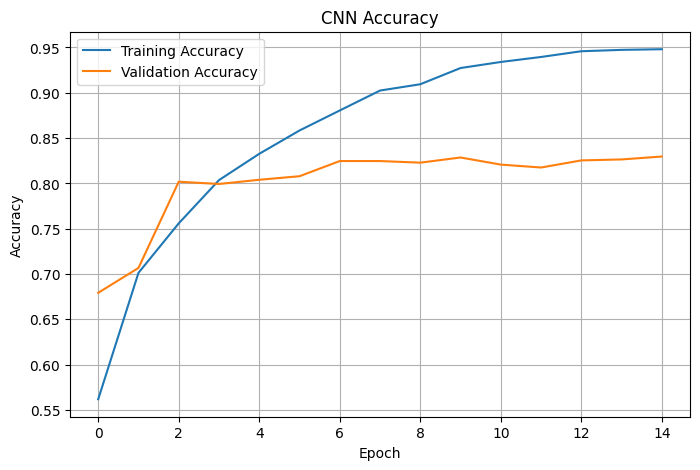

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()
plt.grid()
plt.show()

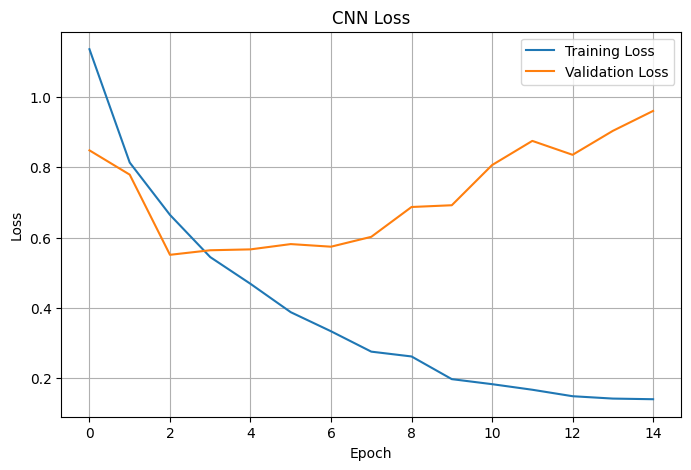

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()
plt.grid()
plt.show()

In [49]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(test_ds)

print("CNN Test Loss:", cnn_loss)
print("CNN Test Accuracy:", cnn_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8220 - loss: 0.9857
CNN Test Loss: 0.9857358336448669
CNN Test Accuracy: 0.8220000267028809


In [50]:
cnn_model.save("cnn_model.keras")

In [51]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [
        ann_accuracy,
        cnn_accuracy
    ],
    "Test Loss": [
        ann_loss,
        cnn_loss
    ]
})

results

,Model,Test Accuracy,Test Loss
0,ANN,0.405333,1.484236
1,CNN,0.822000,0.985736


In [52]:
if cnn_accuracy > ann_accuracy:
    winner = "CNN"
    best_model = cnn_model
else:
    winner = "ANN"
    best_model = ann_model

print("Winning Model:", winner)

Winning Model: CNN


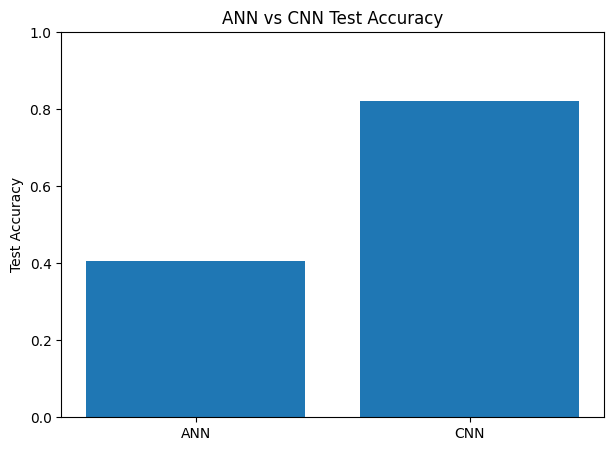

In [53]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["ANN", "CNN"],
    [ann_accuracy, cnn_accuracy]
)

plt.ylabel("Test Accuracy")
plt.title("ANN vs CNN Test Accuracy")
plt.ylim(0, 1)

plt.show()

In [54]:
best_model.save("best_model.keras")

In [55]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Winning model:", winner)
print("Classes:", class_names)

Winning model: CNN
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [56]:
from tensorflow.keras.utils import load_img, img_to_array

In [57]:
sample_class = class_names[0]

sample_folder = os.path.join(
    TEST_DIR,
    sample_class
)

sample_image = os.listdir(sample_folder)[0]

sample_path = os.path.join(
    sample_folder,
    sample_image
)

print(sample_path)

dataset/seg_test/seg_test/buildings/23727.jpg


In [58]:
img = load_img(
    sample_path,
    target_size=IMG_SIZE
)

img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [59]:
prediction = best_model.predict(img_array)

predicted_index = np.argmax(prediction[0])

predicted_class = class_names[predicted_index]

confidence = prediction[0][predicted_index]

print("Predicted Class:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 651ms/step
Predicted Class: buildings
Confidence: 0.8130194


In [60]:
!pip install -q gradio

In [61]:
import gradio as gr

In [62]:
model = keras.models.load_model("best_model.keras")

In [63]:
def predict_image(image):

    image = image.resize(IMG_SIZE)

    image_array = np.array(image)

    image_array = image_array / 255.0

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    prediction = model.predict(image_array)[0]

    results = {
        class_names[i]: float(prediction[i])
        for i in range(len(class_names))
    }

    return results

In [64]:
demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=6),
    title="ANN vs CNN Image Classifier",
    description="Upload an image to classify it into one of six scene categories."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://106a25a36a95ed87b8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [65]:
import gradio as gr

def predict_image(image):

    image = image.convert("RGB")
    image = image.resize(IMG_SIZE)

    image_array = np.array(image) / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    prediction = model.predict(image_array, verbose=0)[0]

    results = {
        class_names[i]: float(prediction[i])
        for i in range(len(class_names))
    }

    return results


demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(
        type="pil",
        label="Upload Image"
    ),
    outputs=gr.Label(
        num_top_classes=6,
        label="Prediction"
    ),
    title="🌍 Scene Image Classification",
    description=(
        "Upload a real-world image and the trained "
        f"{winner} model will classify it into one of six categories."
    )
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a9102618cd689e1889.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
